# Exploratory Spatial Mapping of Raster Data
This Jupyter Notebook imports a Python libraries to nadle raster data, including a custom-made function to read the Esri-generated PGWX files that include each raster's Affine Transformation data. The files are all saved in the 'GeoreferencedRasters' directory.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# Assign the project root path to a variable:
project_root = Path.cwd().parent

# Change the directory to the project root level:
os.chdir(project_root)

Create a raster dictionary of the PNG file name and its filepath:

In [2]:
# Assign the raster dir to a variable:
raster_directory = project_root / "Data" / "GeoreferencedRasters"

# Create a dictionary of PNG file names and filepath: 
raster_paths = {
    f"{raster_path.parent.name}/{raster_path.stem}": raster_path
    for raster_path in sorted(raster_directory.rglob("*.png"))
}

# Print the raster file name (the dictionary key) and its relative path (the value):
for key, value in raster_paths.items():
    print(f'{key}:', value.relative_to(project_root))

Kirkland/2022_24_AADT: Data\GeoreferencedRasters\Kirkland\2022_24_AADT.png
Redmond/2022_CW_AADT: Data\GeoreferencedRasters\Redmond\2022_CW_AADT.png
Redmond/2022_DT_AADT: Data\GeoreferencedRasters\Redmond\2022_DT_AADT.png
Redmond/2024_CW_AADT: Data\GeoreferencedRasters\Redmond\2024_CW_AADT.png
Redmond/2024_DT_AADT: Data\GeoreferencedRasters\Redmond\2024_DT_AADT.png
Sammamish/2017_25_AADT: Data\GeoreferencedRasters\Sammamish\2017_25_AADT.png


Execute the custom function for each dictionary item that was eneumerated in the above cell's output. Print each file's name, its projection, affine tranformations and bounding box:

In [4]:
import warnings

from rasterio.errors import NotGeoreferencedWarning
from rasterio.transform import array_bounds

from utils.affine_transformation import read_world_file

# The raster is intentionally georeferenced using the external world file.
warnings.filterwarnings(
    "ignore",
    category = NotGeoreferencedWarning
)

CRS = "EPSG:2926"

for dict_key, dict_value in raster_paths.items():
    pgwx_path = dict_value.with_suffix(".pgwx")
    transform = read_world_file(pgwx_path)

    with rasterio.open(dict_value) as r:
        bounds = array_bounds(
            r.height,
            r.width,
            transform
        )

    print(f"\n{dict_key}")
    print(f"Spatial Reference System: {CRS}")
    print(f"Affine Transformations:\n{transform}")
    print(f"Bounding Box: {bounds}")


Kirkland/2022_24_AADT
Spatial Reference System: EPSG:2926
Affine Transformations:
| 22.73, 0.01, 1287303.38|
| 0.01,-22.73, 272604.93|
| 0.00, 0.00, 1.00|
Bounding Box: (1287303.3841171043, 234421.47239124577, 1330613.0671752992, 272618.95517199463)

Redmond/2022_CW_AADT
Spatial Reference System: EPSG:2926
Affine Transformations:
| 7.72,-0.00, 1312323.54|
|-0.00,-7.72, 262487.93|
| 0.00, 0.00, 1.00|
Bounding Box: (1312321.51814305, 231288.52868012903, 1333989.8890081297, 262487.9335546552)

Redmond/2022_DT_AADT
Spatial Reference System: EPSG:2926
Affine Transformations:
| 3.84,-0.10, 1321227.21|
|-0.06,-5.68, 251457.95|
| 0.00, 0.00, 1.00|
Bounding Box: (1321148.3445871077, 246905.06555332692, 1325286.2944636585, 251457.95277909114)

Redmond/2024_CW_AADT
Spatial Reference System: EPSG:2926
Affine Transformations:
| 9.20,-0.00, 1312253.00|
|-0.00,-9.20, 262687.81|
| 0.00, 0.00, 1.00|
Bounding Box: (1312247.3365365276, 231341.54914299914, 1333984.7846952165, 262687.8058578209)

Redmond/

Plot each raster file:

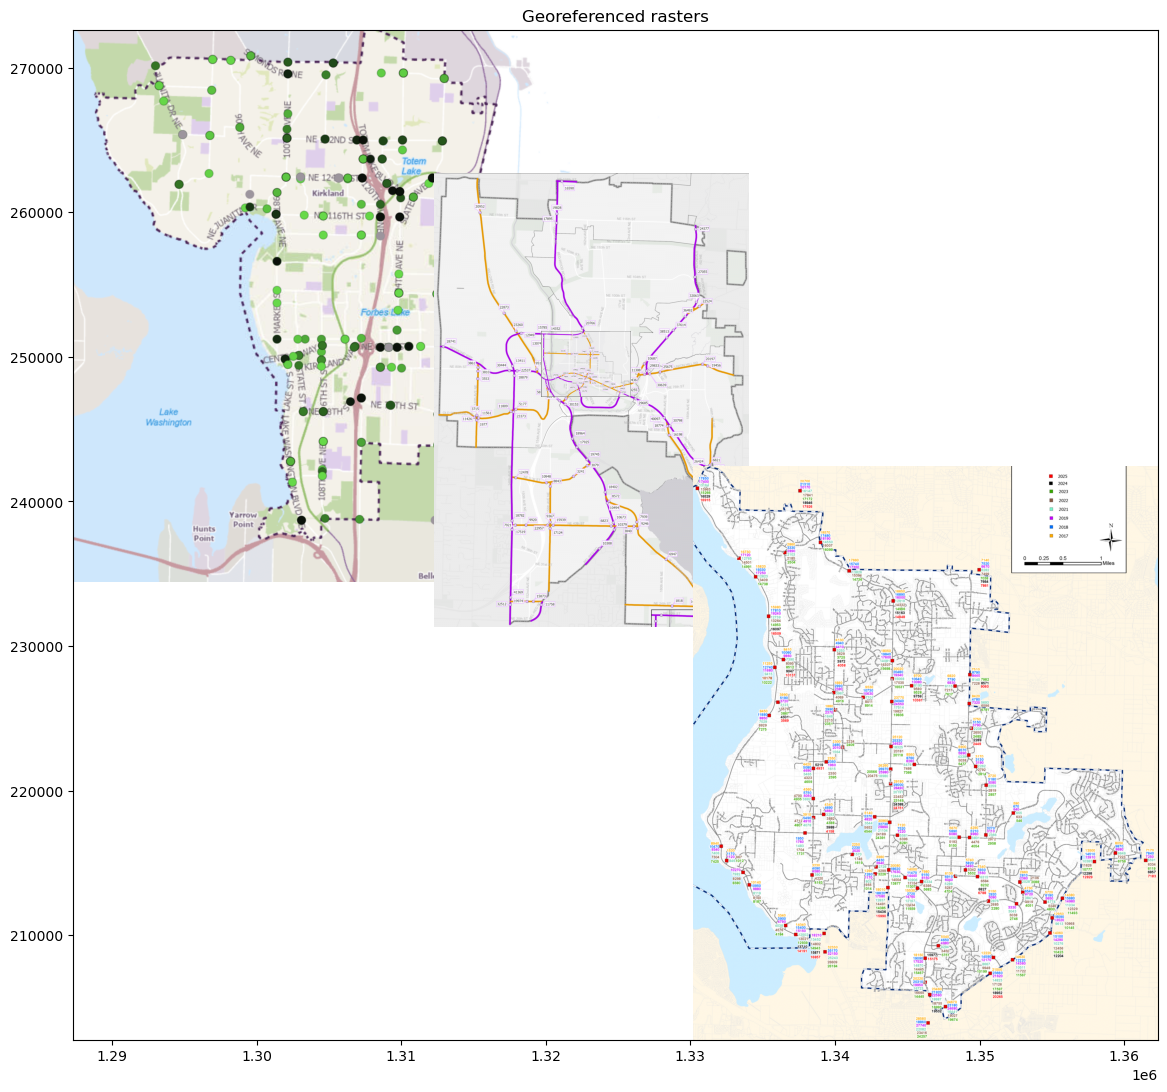

In [5]:
fig, ax = plt.subplots(figsize=(14, 14))

all_bounds = []

for name, png_path in raster_paths.items():
    pgwx_path = png_path.with_suffix(".pgwx")

    transform = read_world_file(pgwx_path)

    with rasterio.open(png_path) as r:
        image = r.read()

        west, south, east, north = array_bounds(
            r.height,
            r.width,
            transform
        )

        all_bounds.append((west, south, east, north))

        show(
            image,
            transform=transform,
            ax=ax,
            alpha=1
        )

# Set axes to the combined extent of every raster
if all_bounds:
    west = min(bounds[0] for bounds in all_bounds)
    south = min(bounds[1] for bounds in all_bounds)
    east = max(bounds[2] for bounds in all_bounds)
    north = max(bounds[3] for bounds in all_bounds)

    ax.set_xlim(west, east)
    ax.set_ylim(south, north)

ax.set_title("Georeferenced rasters")
ax.set_aspect("equal")

plt.show()

**----- END OF NOTEBOOK ----------**